In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(0)
print('GPU:', tf.config.list_physical_devices('GPU'))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()
ZIP_PATH = next(iter(uploaded))
EXTRACT_DIR = '/content/flowers17'

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print('extracted from:', ZIP_PATH)
print(os.listdir(EXTRACT_DIR))

Saving 17Flower.zip to 17Flower.zip
extracted from: 17Flower.zip
['17flowerclasses']


In [39]:
DATA_DIR = f'{EXTRACT_DIR}/17flowerclasses'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = keras.utils.image_dataset_from_directory(
    f'{DATA_DIR}/train',
    validation_split=0.15,
    subset='training',
    seed=0,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

valid_ds = keras.utils.image_dataset_from_directory(
    f'{DATA_DIR}/train',
    validation_split=0.15,
    subset='validation',
    seed=0,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

test_ds = keras.utils.image_dataset_from_directory(
    f'{DATA_DIR}/test',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print('calss:', class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
valid_ds = valid_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 1190 files belonging to 17 classes.
Using 1012 files for training.
Found 1190 files belonging to 17 classes.
Using 178 files for validation.
Found 170 files belonging to 17 classes.
calss: ['Bluebell', 'ButterCup', 'ColtsFoot', 'Cowslip', 'Crocus', 'Daffodil', 'Daisy', 'Dandelion', 'Fritillary', 'Iris', 'LilyValley', 'Pansy', 'Snowdrop', 'Sunflower', 'Tigerlily', 'WindFlower', 'tulip']


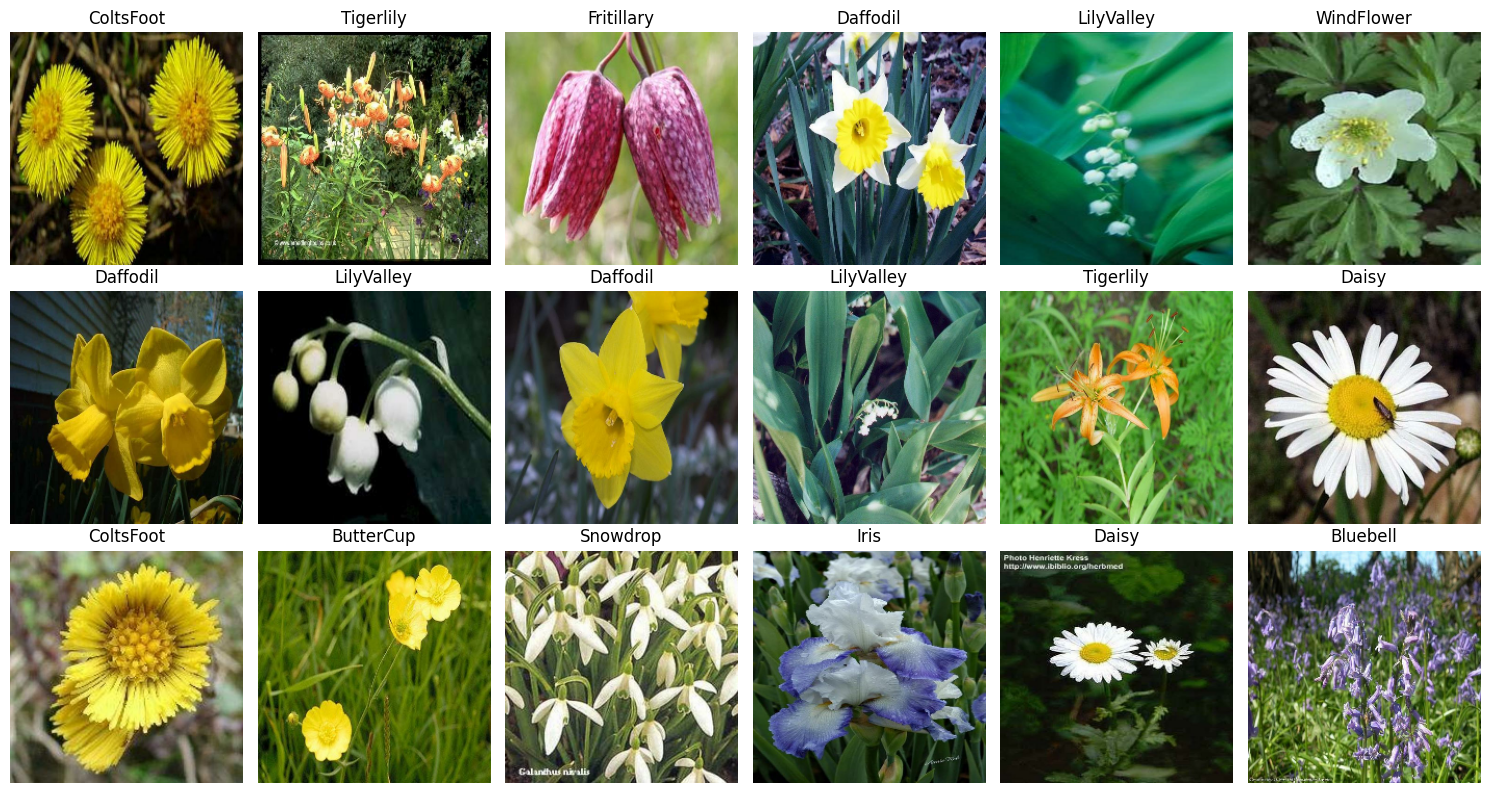

In [46]:
plt.figure(figsize=(15, 8))
for images, labels in train_ds.take(1):
    for i in range(18):
        plt.subplot(3, 6, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]])
        plt.axis('off')
plt.tight_layout()
plt.show()

In [47]:
augment = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
])

base_model = keras.applications.MobileNetV2(
    input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet'
)
base_model.trainable = False

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = augment(inputs)
x = keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = keras.Model(inputs, outputs)
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_5 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_5 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 17)             │        21,777 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,279,761 (8.70 MB)

 Trainable params: 21,777 (85.07 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [48]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=6, restore_best_weights=True
)

history1 = model.fit(train_ds, validation_data=valid_ds, epochs=25, callbacks=[early_stop])

Epoch 1/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 122ms/step - accuracy: 0.3083 - loss: 2.2920 - val_accuracy: 0.7753 - val_loss: 1.2017
Epoch 2/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.7134 - loss: 1.0448 - val_accuracy: 0.8483 - val_loss: 0.7231
Epoch 3/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.8053 - loss: 0.7055 - val_accuracy: 0.9270 - val_loss: 0.5114
Epoch 4/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.8636 - loss: 0.5385 - val_accuracy: 0.9270 - val_loss: 0.4275
Epoch 5/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.8893 - loss: 0.4330 - val_accuracy: 0.9213 - val_loss: 0.3709
Epoch 6/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.8953 - loss: 0.3849 - val_accuracy: 0.9270 - val_loss: 0.3369
Epoch 7/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.9170 - loss: 0.3223 - val_accuracy: 0.9326 - val_loss: 0.3072
Epoch 8/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.9318 - loss: 0.2766 - val_accuracy: 0.9438

In [49]:
base_model.trainable = True
for layer in base_model.layers[:-60]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(train_ds, validation_data=valid_ds, epochs=30, callbacks=[early_stop])


Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 163ms/step - accuracy: 0.9516 - loss: 0.1801 - val_accuracy: 0.9494 - val_loss: 0.1940
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.9516 - loss: 0.1551 - val_accuracy: 0.9382 - val_loss: 0.2055
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - accuracy: 0.9496 - loss: 0.1490 - val_accuracy: 0.9551 - val_loss: 0.1893
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - accuracy: 0.9674 - loss: 0.1158 - val_accuracy: 0.9494 - val_loss: 0.1719
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.9674 - loss: 0.1093 - val_accuracy: 0.9382 - val_loss: 0.1909
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.9773 - loss: 0.0900 - val_accuracy: 0.9494 - val_loss: 0.1744
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - accuracy: 0.9812 - loss: 0.0729 - val_accuracy: 0.9551 - val_loss: 0.1757
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - accuracy: 0.9704 - loss: 0.0841 - val_accuracy: 0.9607 -

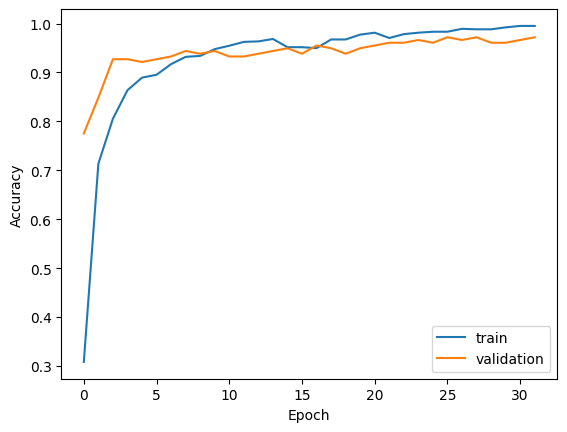

In [50]:
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']

plt.plot(acc, label='train')
plt.plot(val_acc, label='validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [51]:
test_loss, test_acc = model.evaluate(test_ds)
print(f'Accuracy on test: {test_acc * 100:.2f}%')

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9059 - loss: 0.2679
Accuracy on test: 90.59%


Saving image_0732.jpg to image_0732.jpg


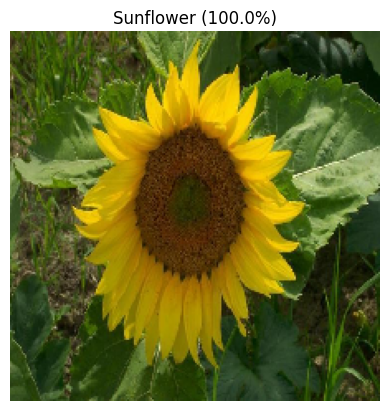

In [53]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    img = keras.utils.load_img(filename, target_size=IMG_SIZE)
    arr = keras.utils.img_to_array(img)
    probs = model.predict(arr[None, ...], verbose=0)[0]
    pred = class_names[np.argmax(probs)]

    plt.imshow(img)
    plt.title(f'{pred} ({probs.max() * 100:.1f}%)')
    plt.axis('off')
    plt.show()